# Machine Learning

In [32]:
# 1. importazione librerie

import pandas as pd
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from pandas.plotting import scatter_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve, GridSearchCV, cross_val_score, StratifiedKFold, train_test_split

In [33]:
# caricamento dataset

data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="class")

df = X.copy()
df["class"] = y
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [34]:
# verifica delle principali caratteristiche del dataset
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)       class  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [36]:
# conta per verificare quante sono le classi

print(df.groupby("class").size())

class
0    50
1    50
2    50
dtype: int64


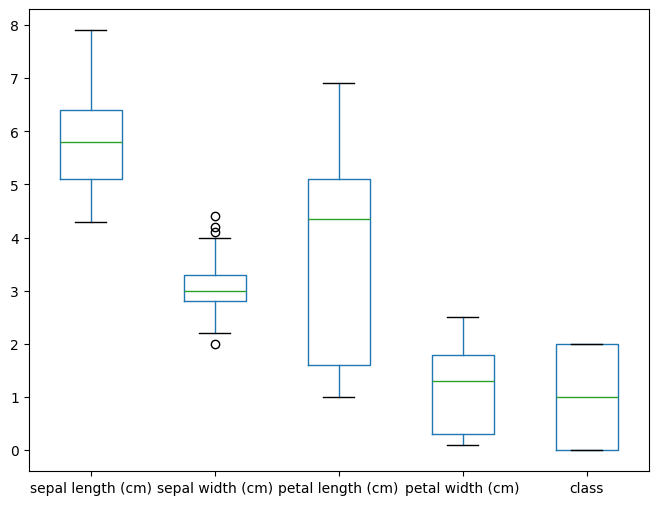

In [37]:
# facciamo grafico per data esploration

df.boxplot(figsize=(8,6), grid=False)
plt.show()

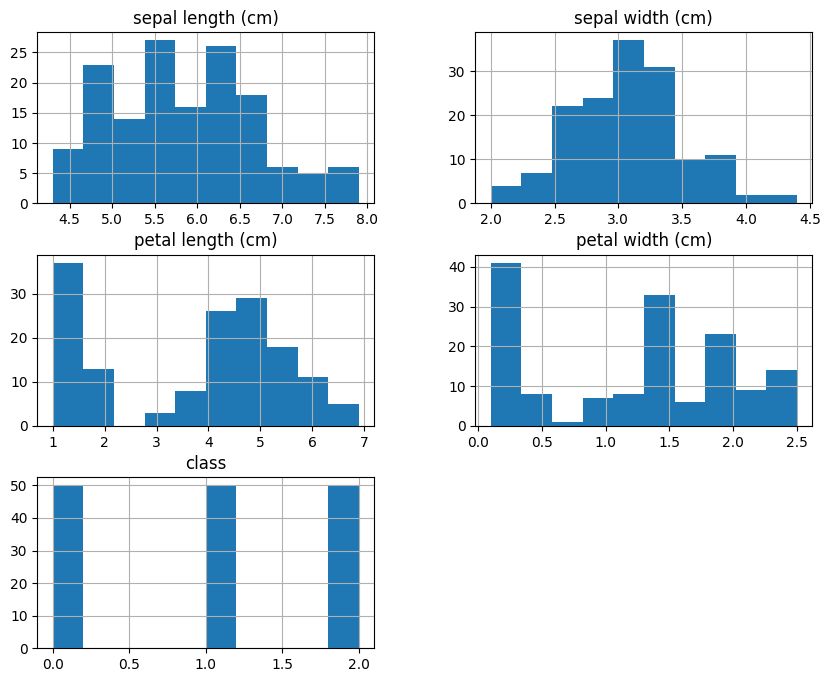

In [38]:
df.hist(figsize=(10,8))
plt.show()

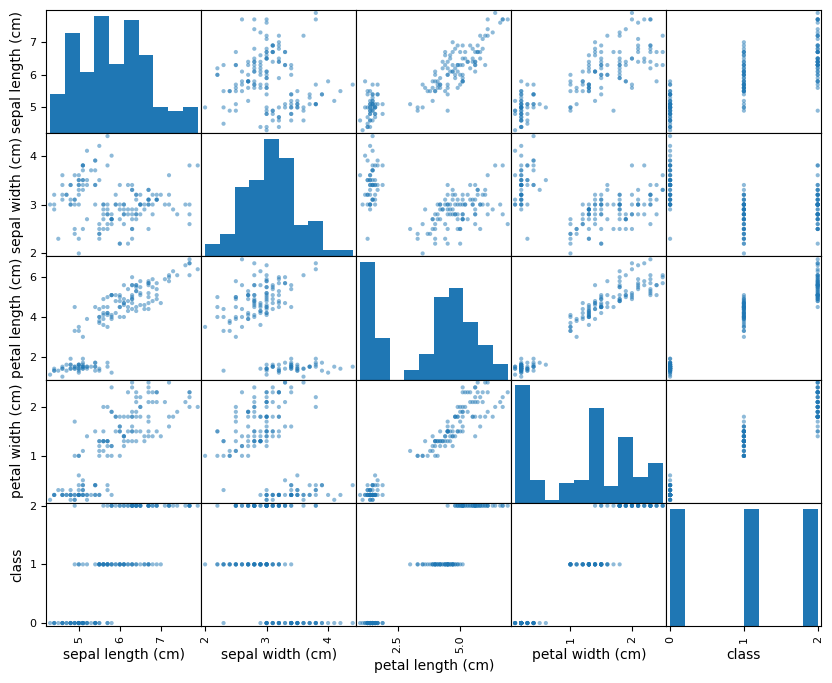

In [39]:
scatter_matrix(df, figsize=(10,8))
plt.show()

# dalla matrice si evince che la correlazione migliore è tra petal legnght e petal eidht per fare la classificazione

In [60]:
# data splitting

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=0.20,
    random_state=42
)

In [61]:
models = [
    ("SVC", SVC(gamma="auto")),
    ("KNN", KNeighborsClassifier()),
    ("CART", DecisionTreeClassifier()),
    ("LR", LogisticRegression(max_iter=1000))
]

In [62]:
# andiamo a calcolare gli score per vedere qual è il modello migliore con parametri default

names = []
results = []
K = 10
for name, model in models:
    kfold = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")
    names.append(name)
    results.append(cv_results)
    print(f"{name}:\n\tMEAN:\t{cv_results.mean():.4f}\n\tSTD:\t{cv_results.std():.4f}")

SVC:
	MEAN:	0.9583
	STD:	0.0417
KNN:
	MEAN:	0.9500
	STD:	0.0408
CART:
	MEAN:	0.9333
	STD:	0.0624
LR:
	MEAN:	0.9500
	STD:	0.0553


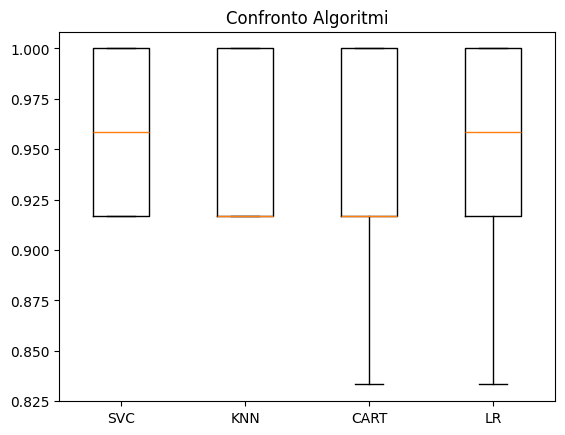

In [63]:
plt.boxplot(results, tick_labels=names)
plt.title("Confronto Algoritmi")
plt.show()

In [64]:
model = SVC(gamma="auto")
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [65]:
print(f"Accuracy:\t{accuracy_score(y_test, predictions):.2f}")

Accuracy:	1.00


In [66]:
print(confusion_matrix(y_test, predictions))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [67]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



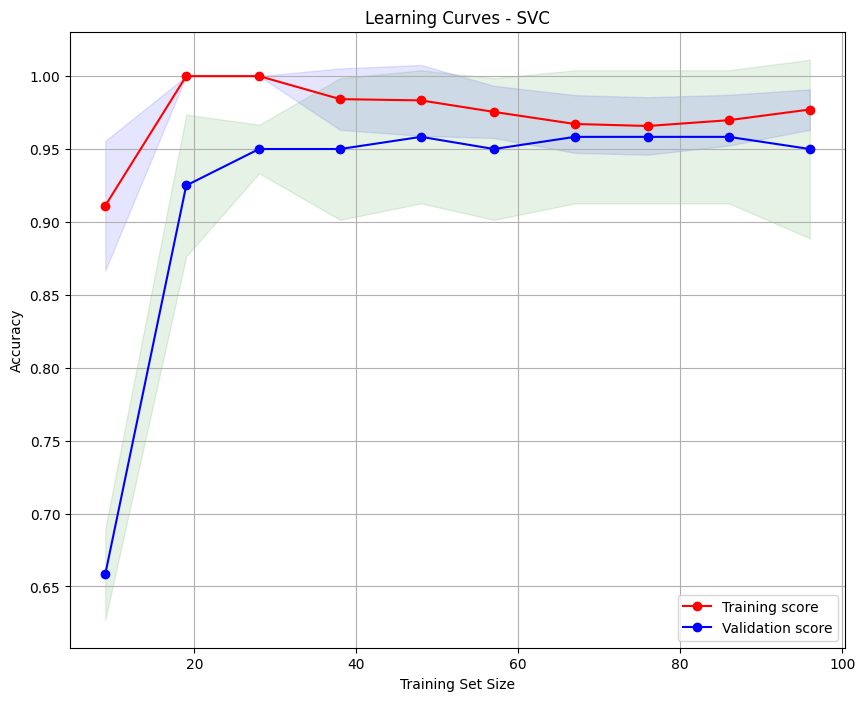

In [68]:
train_sizes, train_scores, val_scores = learning_curve(
    model, 
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
    train_sizes = np.linspace(0.1, 1.0, 10)
) 

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis = 1)
val_mean = np.mean(val_scores, axis =1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize = (10,8))
plt.plot(train_sizes, train_mean, 'o-', color='red', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='blue', label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='green')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves - SVC')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [69]:
# vediamo se riusciamo ad ottimizzare ancora di più il modello ottimizzando solo il parametro c

svc = SVC(gamma='auto')

param_grid = {
    'C': np.logspace(-2, 2, 5),
    }

grid = GridSearchCV(
    cv=5,
    n_jobs=-1,
    estimator=svc,
    scoring='accuracy',
    param_grid=param_grid
    )

grid.fit(X_train, y_train)

print(f"C:\t{grid.best_params_['C']}")
print(f"CV:\t{grid.best_score_:.3f}")

best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)

C:	10.0
CV:	0.958


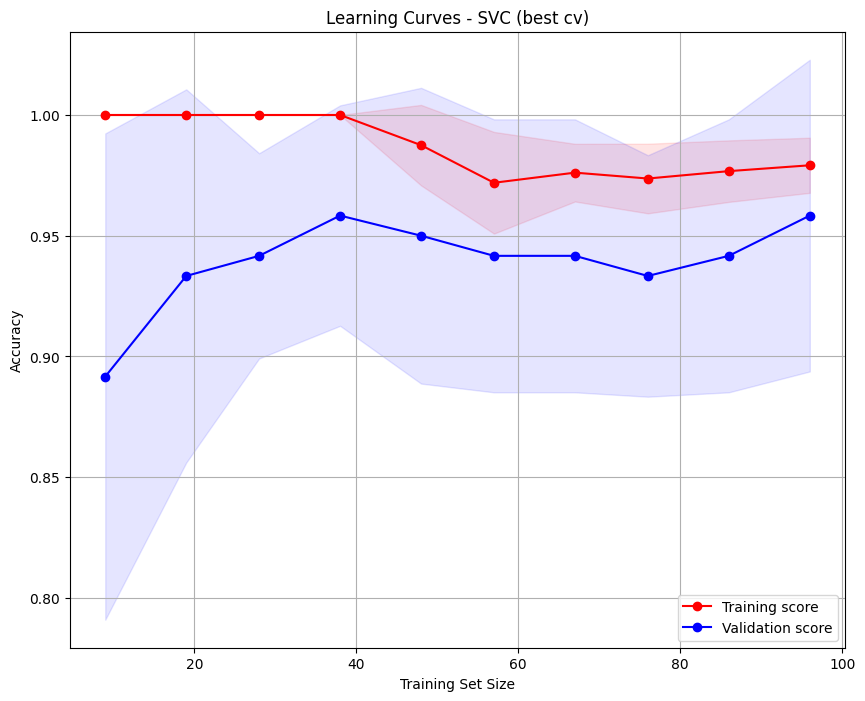

In [72]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, 
    X_train,
    y_train,
    cv=5,
    n_jobs=1,
    scoring="accuracy",
    train_sizes = np.linspace(0.1, 1.0, 10)
) 

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis = 1)
val_mean = np.mean(val_scores, axis =1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize = (10,8))
plt.plot(train_sizes, train_mean, 'o-', color='red', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='red')
plt.plot(train_sizes, val_mean, 'o-', color='blue', label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='blue')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves - SVC (best cv)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

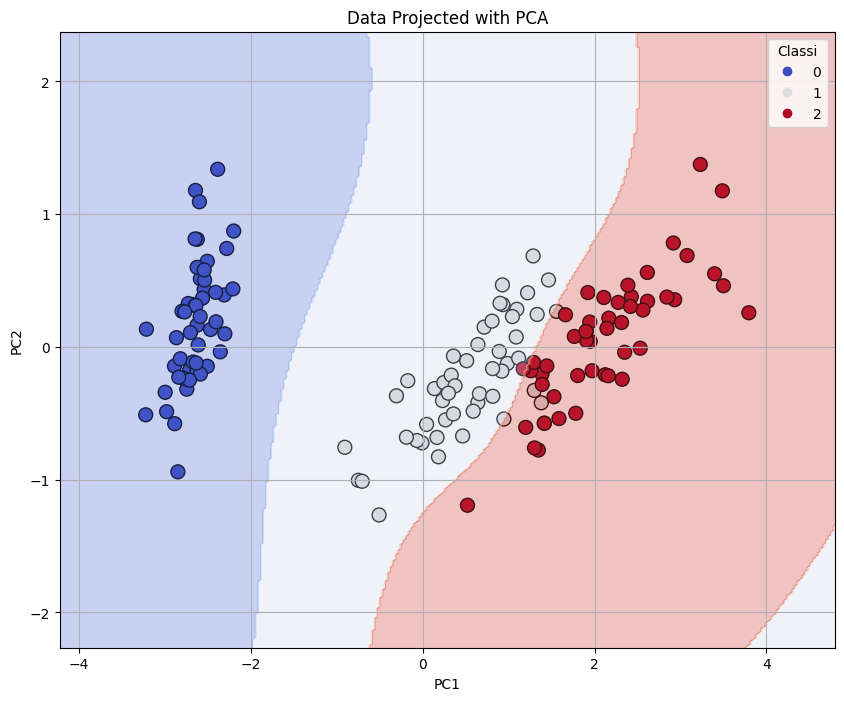

In [71]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
best_model.fit(X_pca, y)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=100)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Data Projected with PCA'),
plt.legend(*scatter.legend_elements(), title='Classi')
plt.grid(True)
plt.show()